In [10]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import scipy.sparse as sp
from collections import Counter

In [11]:
expression_path = "/home/sander/apps/prot_GPT/transcriptomics/output/expression.npz"
metadata_path = "/home/sander/apps/prot_GPT/transcriptomics/output/metadata.parquet"
protein_columns_path = "/home/sander/apps/prot_GPT/transcriptomics/output/protein_columns.json"

# Load data
meta = pd.read_parquet(metadata_path)
with open(protein_columns_path) as f:
    protein_columns = json.load(f)

loader = np.load(expression_path)
expr = sp.csr_matrix((loader["data"], loader["indices"], loader["indptr"]), shape=tuple(loader["shape"]))

print(f"Expression matrix: {expr.shape[0]:,} cells × {expr.shape[1]:,} proteins")
print(f"Non-zero entries: {expr.nnz:,} ({expr.nnz / (expr.shape[0] * expr.shape[1]) * 100:.1f}% dense)")
print(f"Metadata: {meta.shape[0]:,} rows × {meta.shape[1]} columns")
print(f"Protein columns: {len(protein_columns):,}")
meta.head()

Expression matrix: 4,550,106 cells × 20,274 proteins
Non-zero entries: 8,956,799,521 (9.7% dense)
Metadata: 4,550,106 rows × 14 columns
Protein columns: 20,274


,dataset_id,cell_type,tissue,tissue_general,disease,donor_id,sex,assay,development_stage,self_reported_ethnicity,raw_sum,nnz,is_primary_data,suspension_type
0,f3ee7613-b27f-4deb-a5aa-1d4f9a2db963,cardiac muscle cell,interventricular septum,heart,hypertrophic cardiomyopathy,HCM1,male,modified STRT-seq,fifth decade stage,Han Chinese,20603.0,4975,True,cell
1,f3ee7613-b27f-4deb-a5aa-1d4f9a2db963,cardiac muscle cell,interventricular septum,heart,hypertrophic cardiomyopathy,HCM1,male,modified STRT-seq,fifth decade stage,Han Chinese,21581.0,4152,True,cell
2,f3ee7613-b27f-4deb-a5aa-1d4f9a2db963,cardiac muscle cell,interventricular septum,heart,hypertrophic cardiomyopathy,HCM1,male,modified STRT-seq,fifth decade stage,Han Chinese,28852.0,4978,True,cell
3,f3ee7613-b27f-4deb-a5aa-1d4f9a2db963,cardiac muscle cell,interventricular septum,heart,hypertrophic cardiomyopathy,HCM1,male,modified STRT-seq,fifth decade stage,Han Chinese,108539.0,7441,True,cell
4,f3ee7613-b27f-4deb-a5aa-1d4f9a2db963,cardiac muscle cell,interventricular septum,heart,hypertrophic cardiomyopathy,HCM1,male,modified STRT-seq,fifth decade stage,Han Chinese,45284.0,6550,True,cell


## Metadata distributions

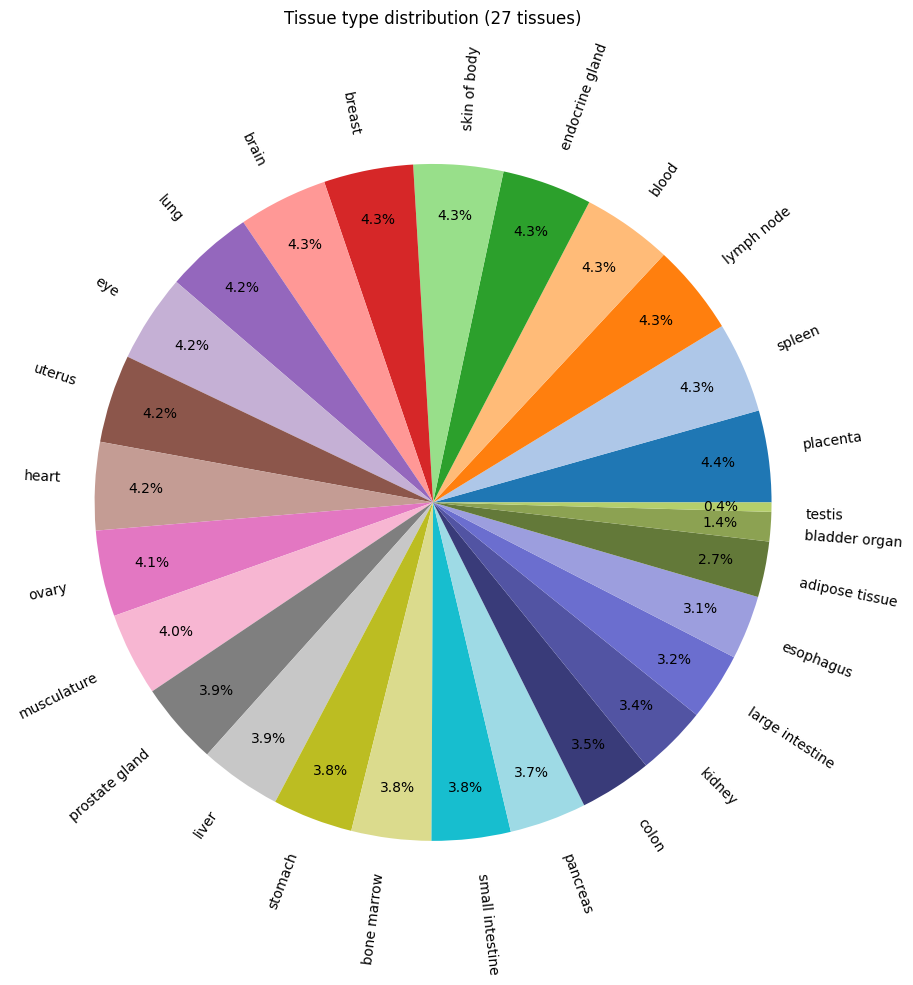

In [12]:
# Tissue type pie chart — only tissues with cells
tissue_counts = meta["tissue_general"].value_counts()
tissue_counts = tissue_counts[tissue_counts > 0]

colors = plt.cm.tab20.colors + plt.cm.tab20b.colors
fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(tissue_counts.values, labels=tissue_counts.index, autopct="%1.1f%%",
       pctdistance=0.85, textprops={"fontsize": 10}, rotatelabels=True,
       colors=[colors[i] for i in range(len(tissue_counts))])
ax.set_title(f"Tissue type distribution ({len(tissue_counts)} tissues)", pad=40)
plt.tight_layout()
plt.show()

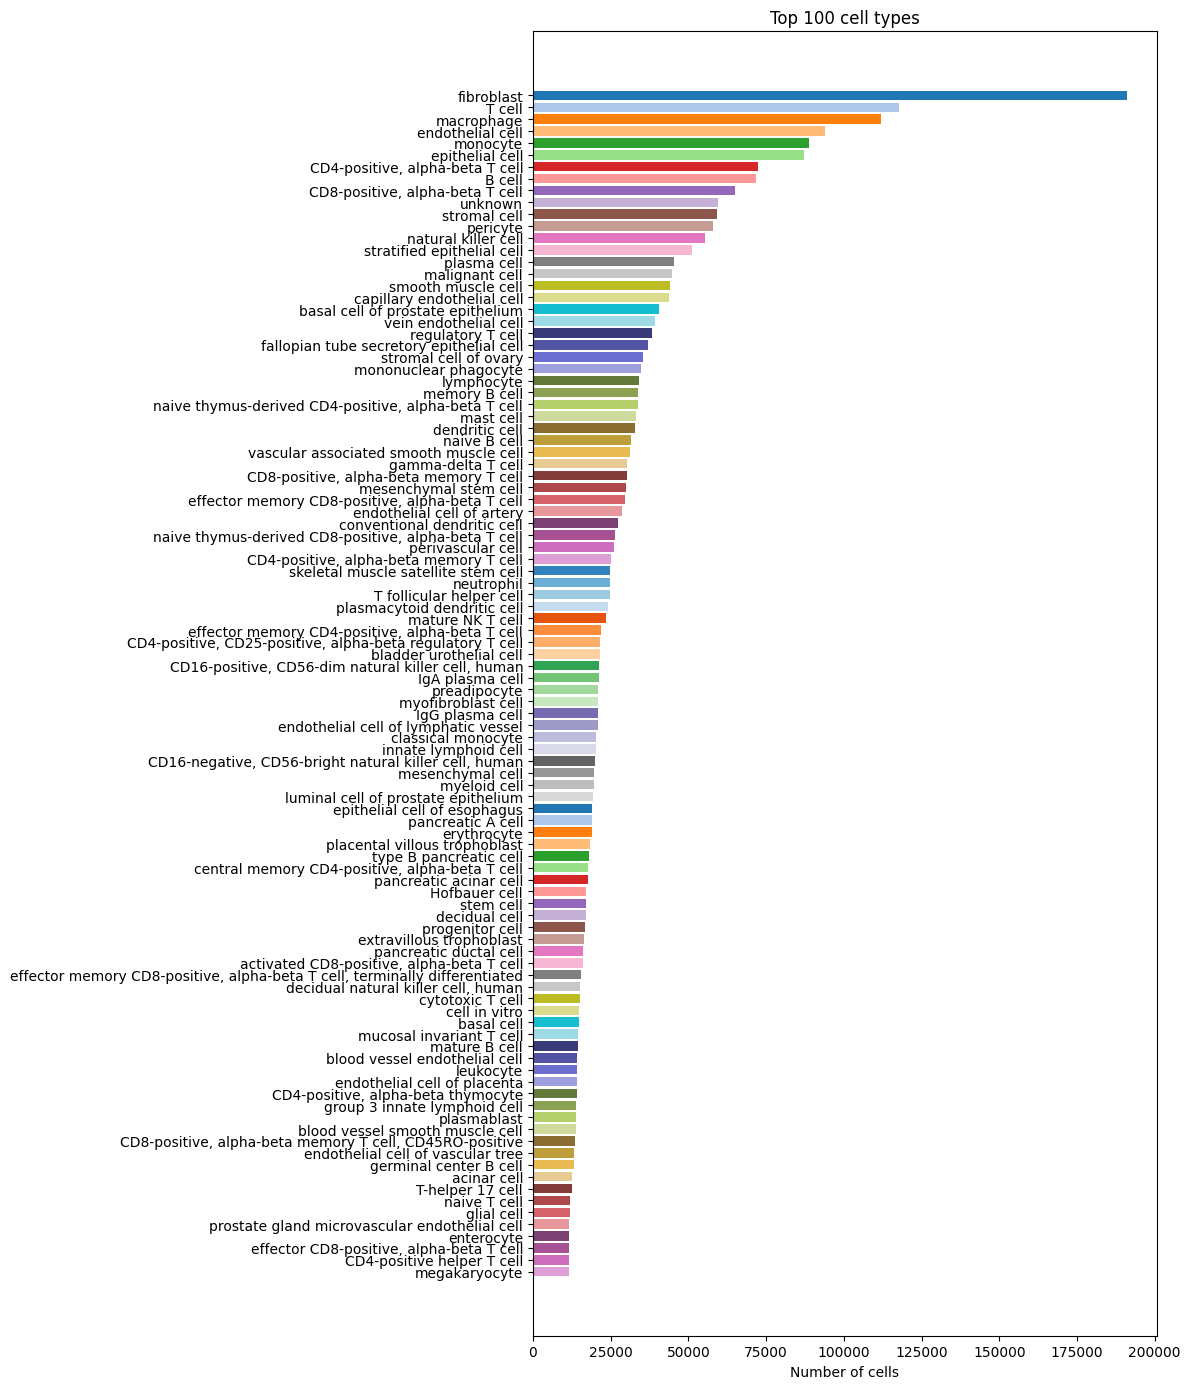

total cell types: 722


In [13]:
# Cell type bar chart — top 60
ct_counts = meta["cell_type"].value_counts()
ct_counts = ct_counts[ct_counts > 0].head(100)

colors = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(ct_counts.index[::-1], ct_counts.values[::-1],
        color=[colors[i % len(colors)] for i in range(len(ct_counts))][::-1])
ax.set_title(f"Top {len(ct_counts)} cell types")
ax.set_xlabel("Number of cells")
plt.tight_layout()
plt.show()

print("total cell types:", meta["cell_type"].nunique())

# dimensionality reduction

Sampled 10,000 cells for dimensionality reduction
Running SVD (50 components)...
  Variance explained: 78.5%
Running UMAP...


/home/sander/miniconda3/envs/prot_gpt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running t-SNE...


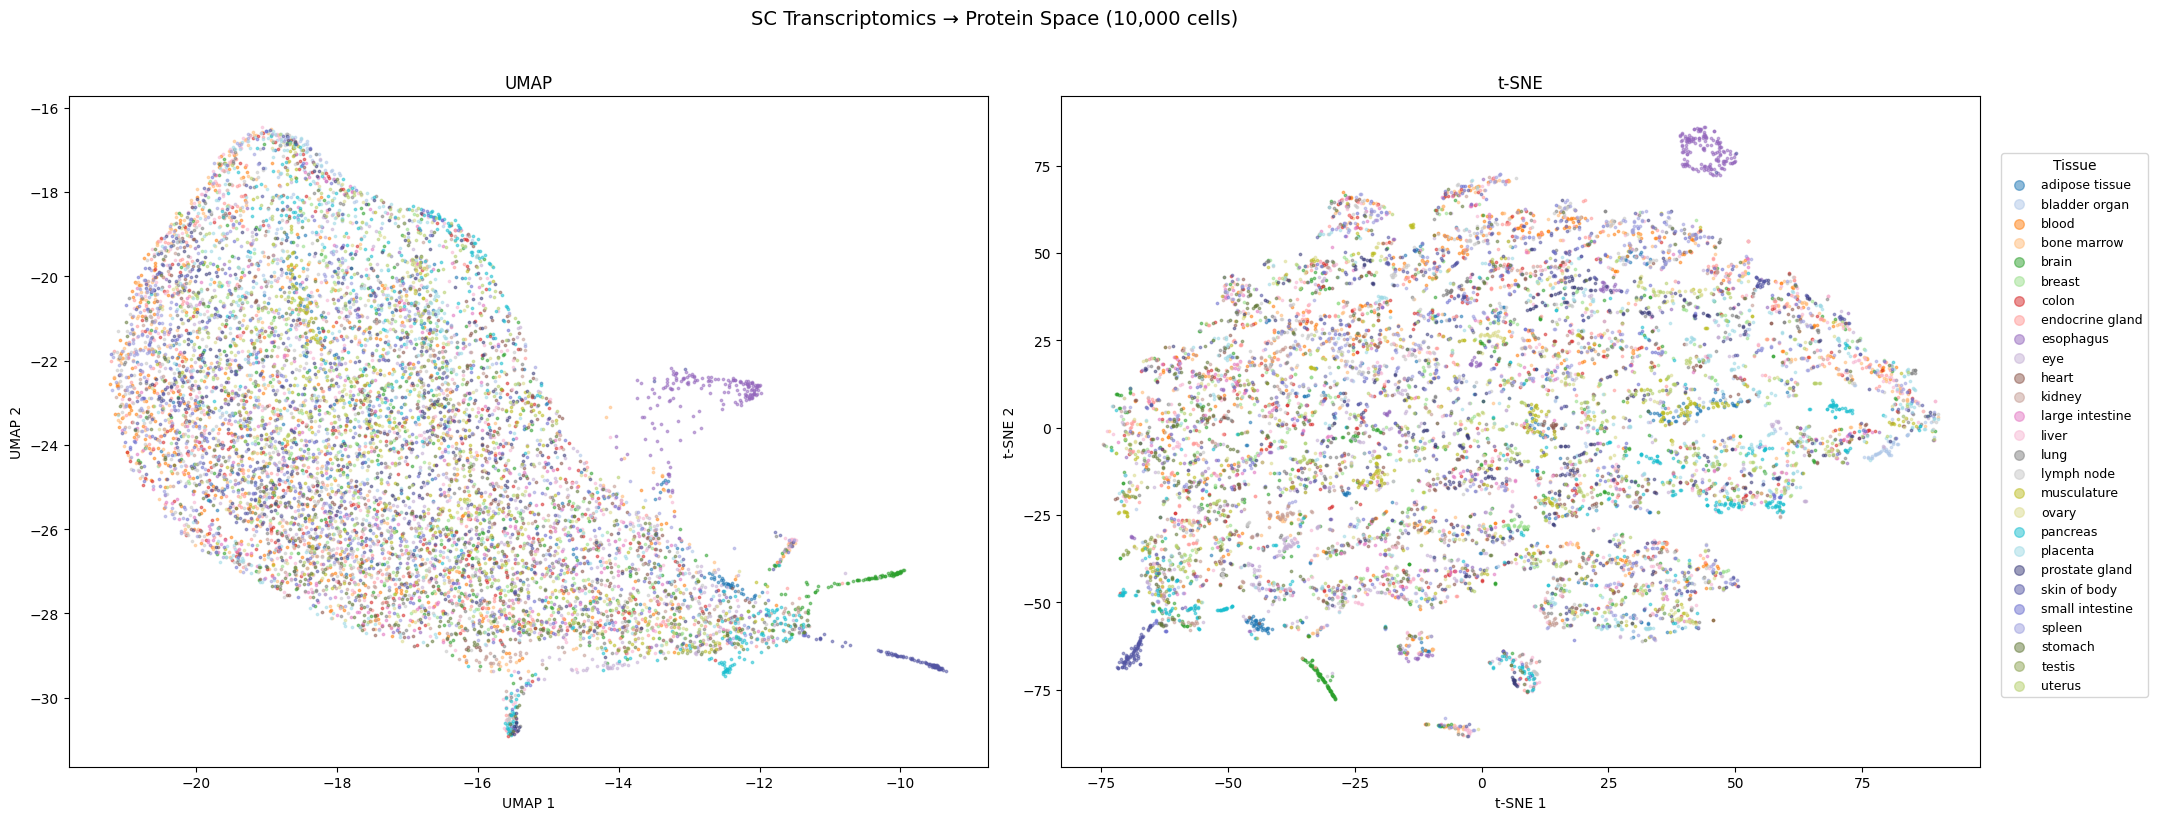

In [18]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from umap import UMAP

# Subsample 10k cells for dimensionality reduction (full dataset too large)
n_sample = 10_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(expr.shape[0], size=n_sample, replace=False)
X_sample = expr[sample_idx]
meta_sample = meta.iloc[sample_idx].reset_index(drop=True)

print(f"Sampled {n_sample:,} cells for dimensionality reduction")

# PCA via TruncatedSVD (works on sparse matrices)
print("Running SVD (50 components)...")
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_sample)
print(f"  Variance explained: {svd.explained_variance_ratio_.sum():.1%}")

# UMAP
print("Running UMAP...")
umap = UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42)
X_umap = umap.fit_transform(X_svd)

# t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_svd)

# Plot side by side, colored by tissue
tissues = meta_sample["tissue_general"].astype(str)
unique_tissues = sorted(tissues.unique())
cmap_colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
tissue_colors = {t: cmap_colors[i] for i, t in enumerate(unique_tissues)}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for t in unique_tissues:
    mask = tissues == t
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], c=[tissue_colors[t]], label=t, s=3, alpha=0.5)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[tissue_colors[t]], label=t, s=3, alpha=0.5)

axes[0].set_title("UMAP")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), 
           markerscale=4, fontsize=9, title="Tissue")

fig.suptitle(f"SC Transcriptomics → Protein Space ({n_sample:,} cells)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Per-cell QC metrics

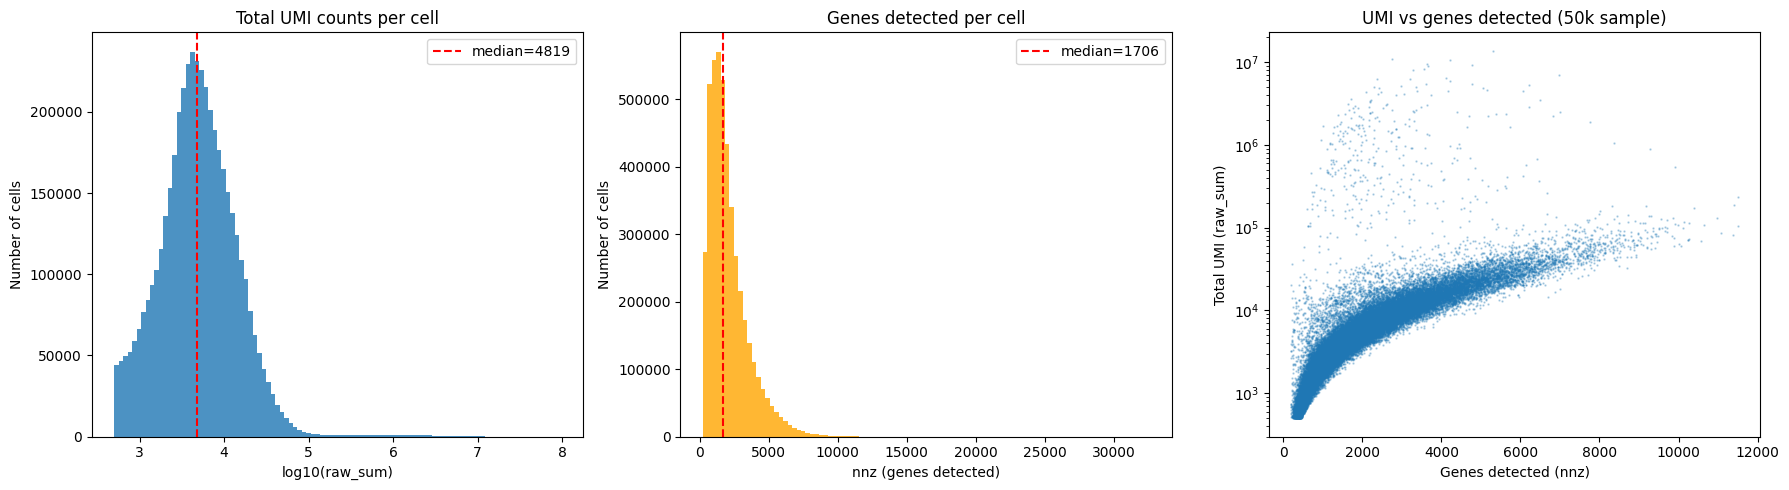

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# raw_sum distribution (log scale)
axes[0].hist(np.log10(meta["raw_sum"]), bins=100, edgecolor="none", alpha=0.8)
axes[0].set_title("Total UMI counts per cell")
axes[0].set_xlabel("log10(raw_sum)")
axes[0].set_ylabel("Number of cells")
axes[0].axvline(np.log10(meta["raw_sum"].median()), color="red", ls="--", label=f'median={meta["raw_sum"].median():.0f}')
axes[0].legend()

# nnz (genes detected) distribution
axes[1].hist(meta["nnz"], bins=100, edgecolor="none", alpha=0.8, color="orange")
axes[1].set_title("Genes detected per cell")
axes[1].set_xlabel("nnz (genes detected)")
axes[1].set_ylabel("Number of cells")
axes[1].axvline(meta["nnz"].median(), color="red", ls="--", label=f'median={meta["nnz"].median():.0f}')
axes[1].legend()

# raw_sum vs nnz scatter (subsample for speed)
idx = np.random.default_rng(42).choice(len(meta), size=min(50_000, len(meta)), replace=False)
axes[2].scatter(meta["nnz"].iloc[idx], meta["raw_sum"].iloc[idx], s=0.5, alpha=0.3)
axes[2].set_xlabel("Genes detected (nnz)")
axes[2].set_ylabel("Total UMI (raw_sum)")
axes[2].set_yscale("log")
axes[2].set_title("UMI vs genes detected (50k sample)")

plt.tight_layout()
plt.show()

## Expression matrix statistics

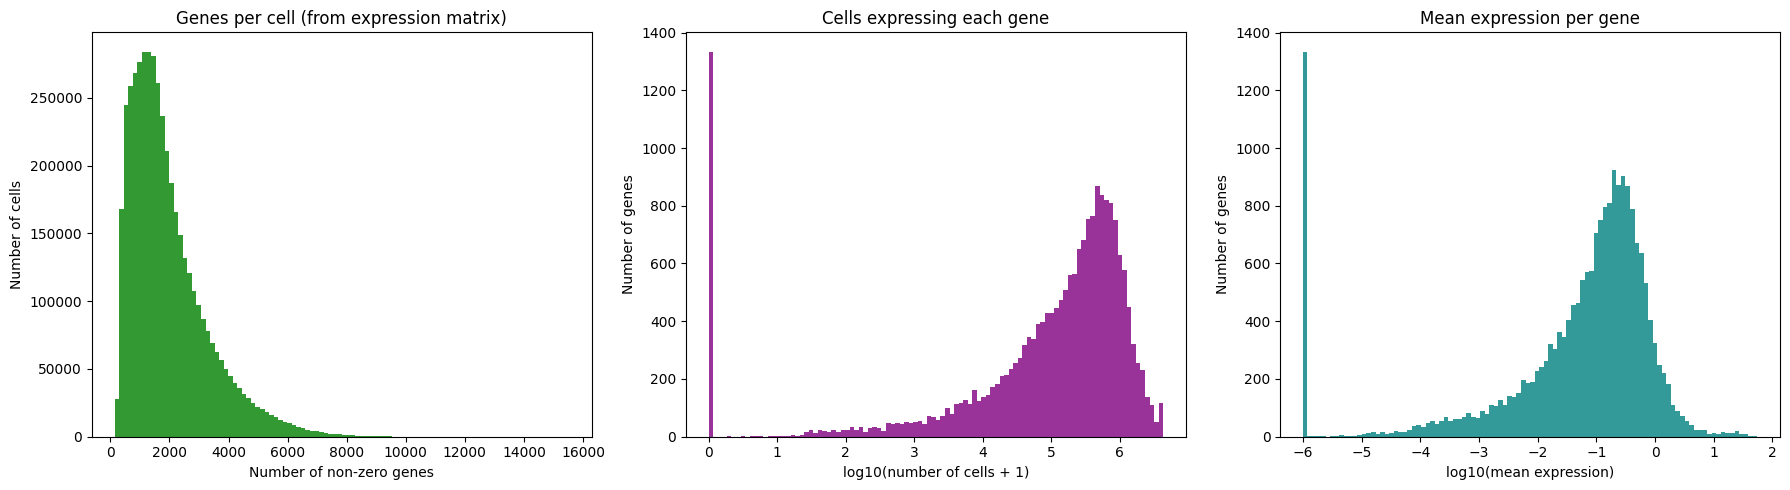

Median genes per cell: 1636
Median cells per gene: 217,294
Genes detected in >50% of cells: 457
Genes detected in <1% of cells: 5649


In [15]:
# Per-protein stats (computed on sparse matrix for efficiency)
genes_per_cell = np.diff(expr.indptr)  # nnz per row
cells_per_gene = expr.getnnz(axis=0)  # cells expressing each gene (no boolean copy)
mean_expr_per_gene = np.array(expr.sum(axis=0)).ravel() / expr.shape[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Genes detected per cell from the expression matrix
axes[0].hist(genes_per_cell, bins=100, edgecolor="none", alpha=0.8, color="green")
axes[0].set_title("Genes per cell (from expression matrix)")
axes[0].set_xlabel("Number of non-zero genes")
axes[0].set_ylabel("Number of cells")

# Cells per gene distribution
axes[1].hist(np.log10(cells_per_gene + 1), bins=100, edgecolor="none", alpha=0.8, color="purple")
axes[1].set_title("Cells expressing each gene")
axes[1].set_xlabel("log10(number of cells + 1)")
axes[1].set_ylabel("Number of genes")

# Mean expression per gene
axes[2].hist(np.log10(mean_expr_per_gene + 1e-6), bins=100, edgecolor="none", alpha=0.8, color="teal")
axes[2].set_title("Mean expression per gene")
axes[2].set_xlabel("log10(mean expression)")
axes[2].set_ylabel("Number of genes")

plt.tight_layout()
plt.show()

print(f"Median genes per cell: {np.median(genes_per_cell):.0f}")
print(f"Median cells per gene: {np.median(cells_per_gene):,.0f}")
print(f"Genes detected in >50% of cells: {(cells_per_gene > expr.shape[0] * 0.5).sum()}")
print(f"Genes detected in <1% of cells: {(cells_per_gene < expr.shape[0] * 0.01).sum()}")

## Per-tissue expression profiles

/tmp/ipykernel_3811460/4264815275.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_stats = meta.groupby("tissue_general")["raw_sum"].describe()[["25%", "50%", "75%"]].loc[tissues]
/tmp/ipykernel_3811460/4264815275.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_nnz = meta.groupby("tissue_general")["nnz"].describe()[["25%", "50%", "75%"]].loc[tissues]


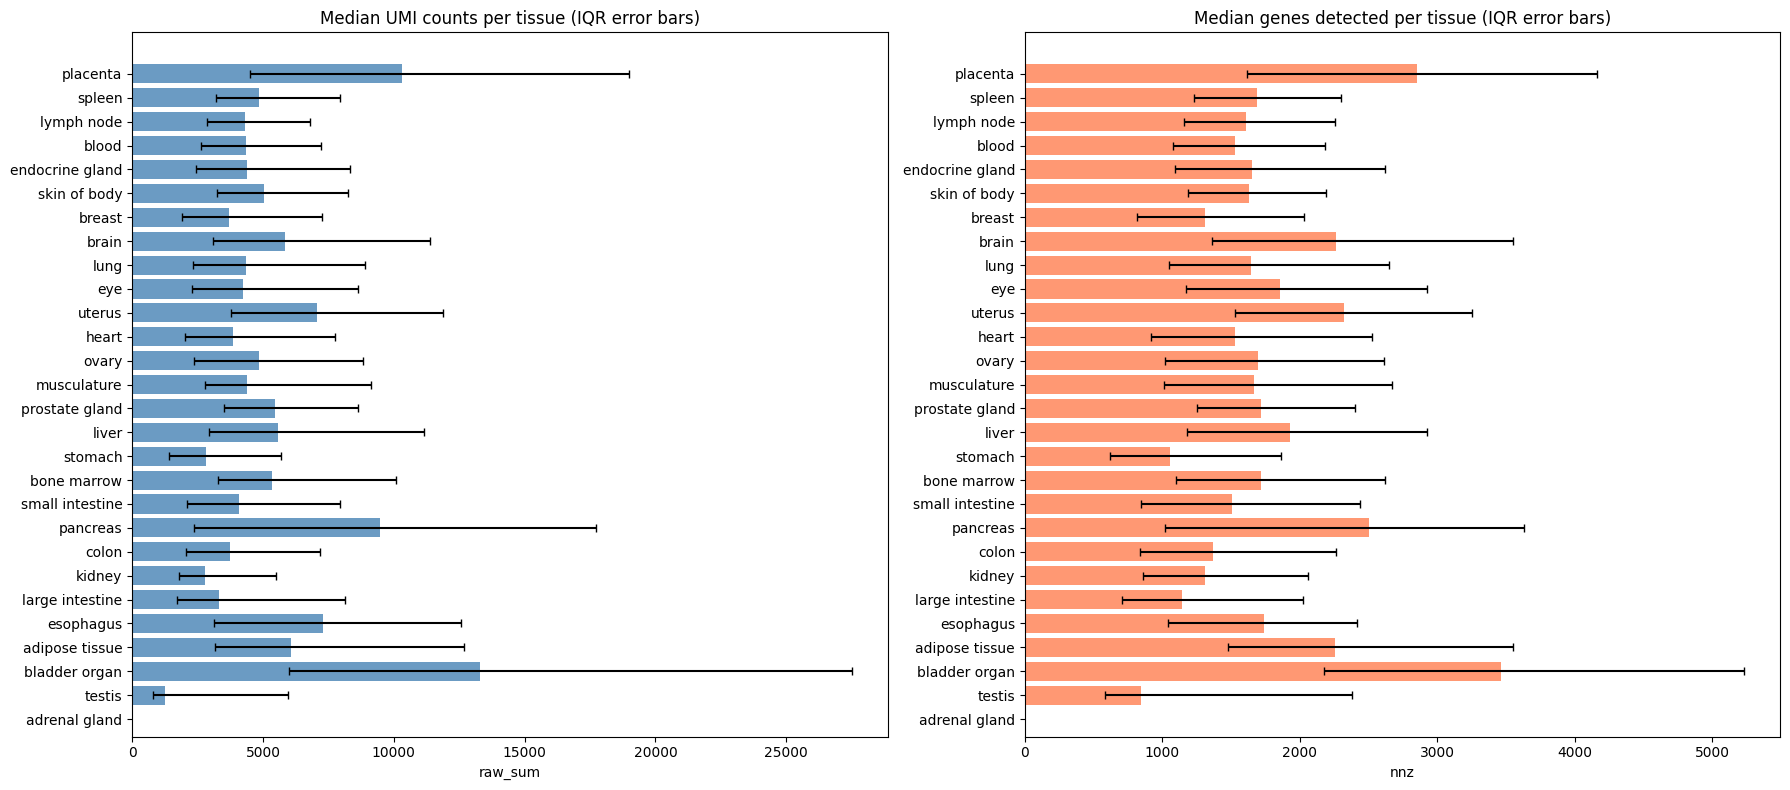

In [16]:
# Compare QC metrics across tissues
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

tissues = meta["tissue_general"].value_counts().index.tolist()

# raw_sum per tissue (boxplot via percentiles for speed)
tissue_stats = meta.groupby("tissue_general")["raw_sum"].describe()[["25%", "50%", "75%"]].loc[tissues]
axes[0].barh(tissue_stats.index[::-1], tissue_stats["50%"].values[::-1], 
             xerr=[tissue_stats["50%"].values[::-1] - tissue_stats["25%"].values[::-1],
                   tissue_stats["75%"].values[::-1] - tissue_stats["50%"].values[::-1]],
             capsize=3, color="steelblue", alpha=0.8)
axes[0].set_title("Median UMI counts per tissue (IQR error bars)")
axes[0].set_xlabel("raw_sum")

# nnz per tissue
tissue_nnz = meta.groupby("tissue_general")["nnz"].describe()[["25%", "50%", "75%"]].loc[tissues]
axes[1].barh(tissue_nnz.index[::-1], tissue_nnz["50%"].values[::-1],
             xerr=[tissue_nnz["50%"].values[::-1] - tissue_nnz["25%"].values[::-1],
                   tissue_nnz["75%"].values[::-1] - tissue_nnz["50%"].values[::-1]],
             capsize=3, color="coral", alpha=0.8)
axes[1].set_title("Median genes detected per tissue (IQR error bars)")
axes[1].set_xlabel("nnz")

plt.tight_layout()
plt.show()

## Dataset and donor diversity

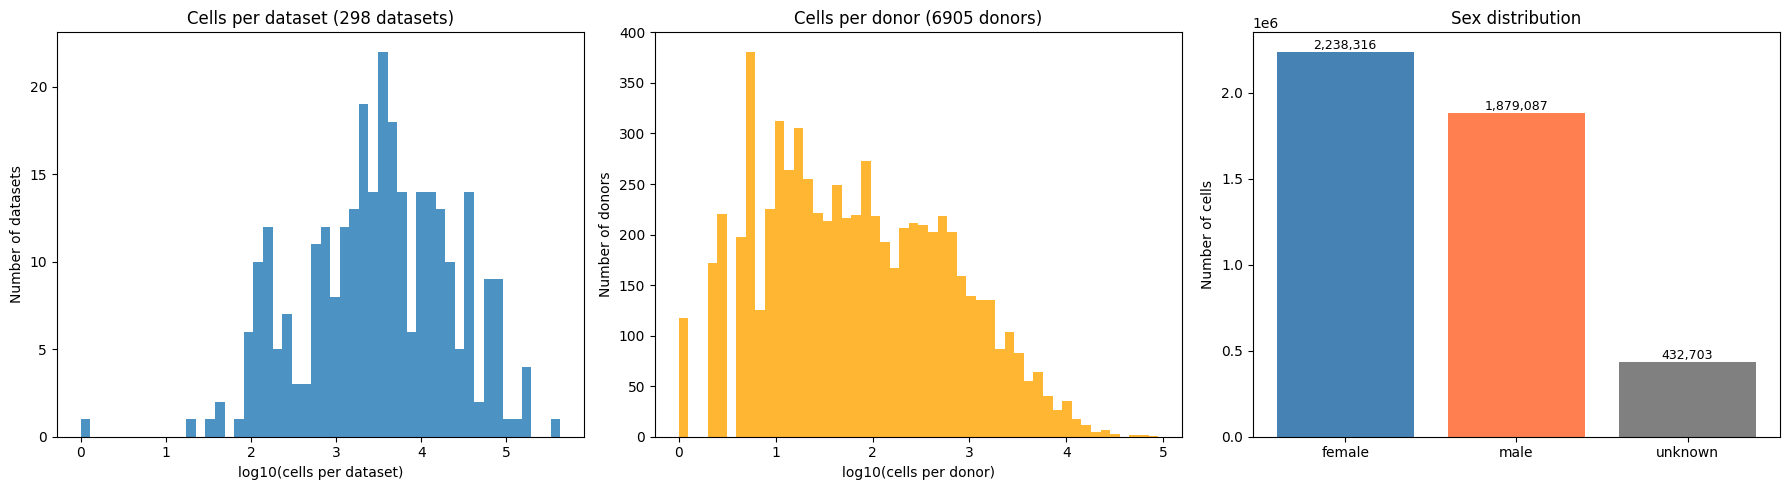

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cells per dataset
ds_counts = meta["dataset_id"].value_counts()
ds_counts = ds_counts[ds_counts > 0]
axes[0].hist(np.log10(ds_counts.values), bins=50, edgecolor="none", alpha=0.8)
axes[0].set_title(f"Cells per dataset ({meta['dataset_id'].nunique()} datasets)")
axes[0].set_xlabel("log10(cells per dataset)")
axes[0].set_ylabel("Number of datasets")

# Cells per donor
donor_counts = meta["donor_id"].value_counts()
donor_counts = donor_counts[donor_counts > 0]
axes[1].hist(np.log10(donor_counts.values), bins=50, edgecolor="none", alpha=0.8, color="orange")
axes[1].set_title(f"Cells per donor ({meta['donor_id'].nunique()} donors)")
axes[1].set_xlabel("log10(cells per donor)")
axes[1].set_ylabel("Number of donors")

# Sex distribution
sex_counts = meta["sex"].value_counts()
axes[2].bar(sex_counts.index, sex_counts.values, color=["steelblue", "coral", "gray", "green"][:len(sex_counts)])
axes[2].set_title("Sex distribution")
axes[2].set_ylabel("Number of cells")
for i, (label, val) in enumerate(zip(sex_counts.index, sex_counts.values)):
    axes[2].text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()